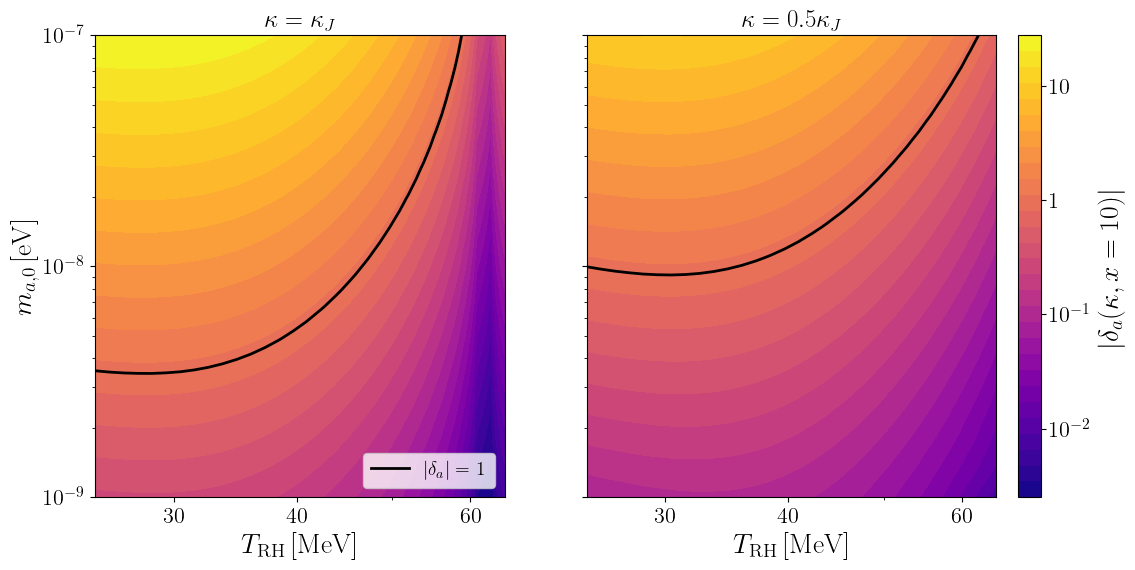

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "pdf.fonttype": 42,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

data = np.load("Sim_Data/Jeans_Grad/jeans_grad_delta_a.npz")

T = data["T_mev"]
ma = data["ma_ev"]
Z_kj = data["delta_kj"]
Z_05kj = data["delta_05kj"]

TT, MM = np.meshgrid(T, ma)

Z_all = np.concatenate([Z_kj.ravel(), Z_05kj.ravel()])
Z_ok = Z_all[np.isfinite(Z_all) & (Z_all > 0.0)]

Z_min = Z_ok.min()
Z_max = Z_ok.max()
levels = np.logspace(np.log10(Z_min), np.log10(Z_max), 30)
norm = mcolors.LogNorm(vmin=Z_min, vmax=Z_max)

def log_fmt(x, pos):
    if x <= 0.0 or not np.isfinite(x):
        return ""
    if np.isclose(x, 1.0):
        return r"$1$"
    if np.isclose(x, 10.0):
        return r"$10$"
    exp = int(np.floor(np.log10(x)))
    coeff = x / 10.0**exp
    if np.isclose(coeff, 1.0):
        return rf"$10^{{{exp}}}$"
    return rf"${coeff:g} \times 10^{{{exp}}}$"

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

plots = [(Z_kj, r"$\kappa=\kappa_J$"), (Z_05kj, r"$\kappa=0.5\kappa_J$")]
xticks = [30, 40, 60]

for i, (ax, (Z, title)) in enumerate(zip(axes, plots)):
    cf = ax.contourf(TT, MM, Z, levels=levels, norm=norm, cmap="plasma", extend="neither")

    Z_valid = Z[np.isfinite(Z)]
    if len(Z_valid) > 0 and Z_valid.min() <= 1.0 <= Z_valid.max():
        ax.contour(TT, MM, Z, levels=[1.0], colors="k", linestyles="solid", linewidths=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(xticks)
    ax.set_xticklabels([rf"${x}$" for x in xticks])
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel(r"$T_{\mathrm{RH}}\,[\mathrm{MeV}]$")
    ax.set_title(title)

    if i == 0:
        ax.set_ylabel(r"$m_{a,0}\,[\mathrm{eV}]$")
        ax.legend([Line2D([0], [0], color="k", lw=2)], [r"$|\delta_a|=1$"], loc="lower right")

cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), pad=0.02, aspect=20)
cbar.ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_fmt))
cbar.ax.yaxis.set_minor_locator(ticker.NullLocator())
cbar.ax.yaxis.set_minor_formatter(ticker.NullFormatter())
cbar.set_label(r"$|\delta_a(\kappa,x=10)|$")

out_dir = Path("Plots/NSC_pert/ALP_perturbations/ALP_delta_a")
out_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(out_dir / "delta_a_2panels.pdf", dpi=300, bbox_inches="tight")
plt.show()